## Modeling and Evaluation

This section presents the development and evaluation of machine learning models for sepsis prediction.

### Model training
The following models were trained:
- Logistic Regression  
- Random Forest  
- XGBoost  

### Model evaluation
Model performance was evaluated using:
- ROC curve comparison  
- Threshold analysis  

### Model interpretability
To understand model predictions, the following interpretability methods were applied:
- Logistic Regression coefficients  
- Random Forest feature importance  
- XGBoost feature importance  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold,  train_test_split
from sklearn.metrics import roc_auc_score, recall_score, f1_score, precision_score, confusion_matrix, classification_report

### Datasets Loading 

In [2]:
df_model_full = pd.read_csv("df_model_full.csv")
df = pd.read_csv("df.csv")
X_tr = pd.read_csv("X_train.csv")
X_te = pd.read_csv("X_test.csv")
y_tr = pd.read_csv("y_train.csv").values.ravel()
y_te = pd.read_csv("y_test.csv").values.ravel()


### Class imbalance visualization

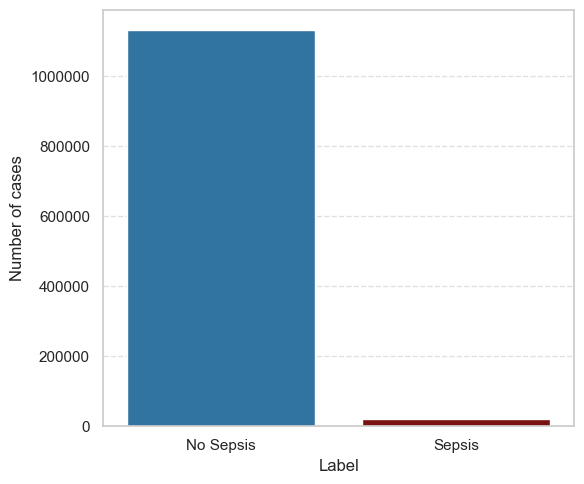

In [3]:

sns.set(style="whitegrid")

# Class distribution
label_counts = df['SepsisLabel'].value_counts().sort_index()

plot_df = pd.DataFrame({
    'Label': ['No Sepsis', 'Sepsis'],
    'Count': [label_counts[0], label_counts[1]]
})

# Bar plot
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=plot_df,
    x='Label',
    y='Count',
    hue='Label',
    palette={'Sepsis':'darkred','No Sepsis':'#1f77b4'},
    legend=False
)

plt.ylabel("Number of cases")

# Y-axis formatting
plt.gca().ticklabel_format(style='plain', axis='y')

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Logistic Regression

In [4]:
from sklearn.linear_model import LogisticRegression

def logistic_regression_model(X_tr, X_te, y_tr, y_te, threshold=0.45):

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    pipe = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            class_weight='balanced',
            solver='liblinear',
            max_iter=1000
        )
    )

    param_grid = {
        'logisticregression__C': [0.01,0.1,1,10]
    }

    grid = GridSearchCV(
        pipe,
        param_grid,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid.fit(X_tr,y_tr)

    model = grid.best_estimator_

    y_proba = model.predict_proba(X_te)[:,1]
    y_pred = (y_proba >= threshold).astype(int)

    print("AUC:", roc_auc_score(y_te,y_proba))
    print("Recall:", recall_score(y_te,y_pred))

    print(confusion_matrix(y_te,y_pred))

    return model, y_proba

In [5]:
model_logreg, y_proba_logreg = logistic_regression_model(X_tr,X_te,y_tr,y_te)


AUC: 0.6985464376474096
Recall: 0.6989120151371807
[[132387  94138]
 [  1273   2955]]


### Random Forest

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

def random_forest_model(X_tr,X_te,y_tr,y_te):

    rf = RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    param = {

        'n_estimators':[100,150,200],
        'max_depth':[5,10],
        'min_samples_split':[20,50],
        'min_samples_leaf':[10,20]
    }

    search = RandomizedSearchCV(
        rf,
        param,
        n_iter=10,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    )

    search.fit(X_tr,y_tr)

    best = search.best_estimator_

    y_proba = best.predict_proba(X_te)[:,1]
    y_pred = (y_proba>=0.45).astype(int)

    print("AUC:",roc_auc_score(y_te,y_proba))

    return best,y_proba

In [7]:
model_rf, y_proba_rf = random_forest_model(X_tr,X_te,y_tr,y_te)


AUC: 0.7655278744078424


### XGBoost

In [8]:
import xgboost as xgb

def xgboost_model(X_tr,X_te,y_tr,y_te):

    scale = (y_tr==0).sum()/(y_tr==1).sum()

    model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        scale_pos_weight=scale,
        random_state=42
    )

    model.fit(X_tr,y_tr)

    y_proba = model.predict_proba(X_te)[:,1]

    print("AUC:",roc_auc_score(y_te,y_proba))

    return model,y_proba

In [9]:
model_xgb, y_proba_xgb = xgboost_model(X_tr,X_te,y_tr,y_te)

AUC: 0.8064581413246933


In [10]:
### full dataset with NaN 

X_full = df_model_full.drop(columns=['SepsisLabel','patient_ID','lp'], errors='ignore')
y_full = df_model_full['SepsisLabel']

X_tr_full, X_te_full, y_tr_full, y_te_full = train_test_split(
    X_full,
    y_full,
    stratify=y_full,
    test_size=0.2,
    random_state=42
)

In [11]:
model_xgb_full, proba_xgb_full = xgboost_model(
    X_tr_full, X_te_full, y_tr_full, y_te_full
)

AUC: 0.8219288540186522


### ROC functions

In [12]:
from sklearn.metrics import roc_curve, auc

def plot_roc(model_names, y_proba_list, y_test):

    plt.figure(figsize=(10,8))

    colors = ['darkred','darkblue','darkgreen']

    for i,(model_name,y_proba) in enumerate(zip(model_names,y_proba_list)):

        fpr,tpr,_ = roc_curve(y_test,y_proba)
        roc_auc = auc(fpr,tpr)

        plt.plot(
            fpr,
            tpr,
            lw=2,
            color=colors[i],
            label=f'{model_name} (AUC = {roc_auc:.3f})'
        )

    plt.plot([0,1],[0,1],'--',color='gray')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve Comparison")

    plt.legend(loc="lower right")

    plt.grid(True)

    plt.show()

### LR, RF and XGBoost comparison

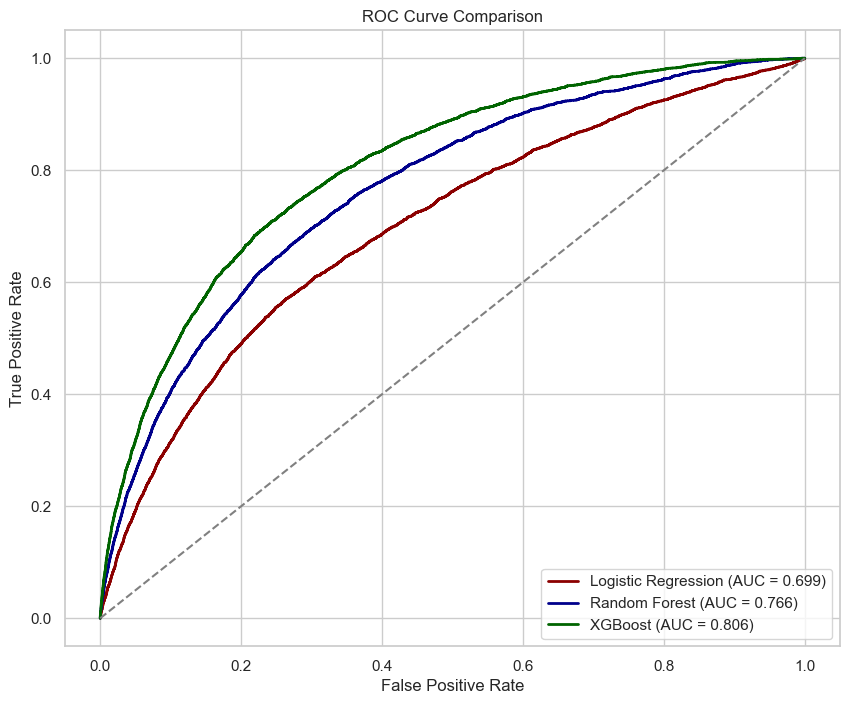

In [13]:
model_names_classical = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]

y_proba_list_classical = [
    y_proba_logreg,
    y_proba_rf,
    y_proba_xgb
]

plot_roc(
    model_names_classical,
    y_proba_list_classical,
    y_te
)

### Threshold analysis

In [14]:
# Function to visualize how classification metrics change with different thresholds
def plot_threshold(y_true, y_proba):

    # Threshold values from 0 to 1
    thresholds = np.arange(0.0, 1.01, 0.01)

    precision_values = []
    recall_values = []
    f1_values = []

    # Compute metrics for each threshold
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        precision_values.append(
            precision_score(y_true, y_pred, zero_division=0)
        )

        recall_values.append(
            recall_score(y_true, y_pred)
        )

        f1_values.append(
            f1_score(y_true, y_pred)
        )

    # Plot metrics
    plt.figure(figsize=(10,6))

    plt.plot(
        thresholds,
        precision_values,
        label="Precision",
        color="darkred",
        linewidth=2
    )

    plt.plot(
        thresholds,
        recall_values,
        label="Recall",
        color="darkgreen",
        linewidth=2
    )

    plt.plot(
        thresholds,
        f1_values,
        label="F1-score",
        color="darkblue",
        linewidth=2
    )

    plt.xlabel("Classification threshold")
    plt.ylabel("Score")
    plt.title("Classification metrics across different thresholds")

    plt.legend()
    plt.grid(True)

    plt.show()

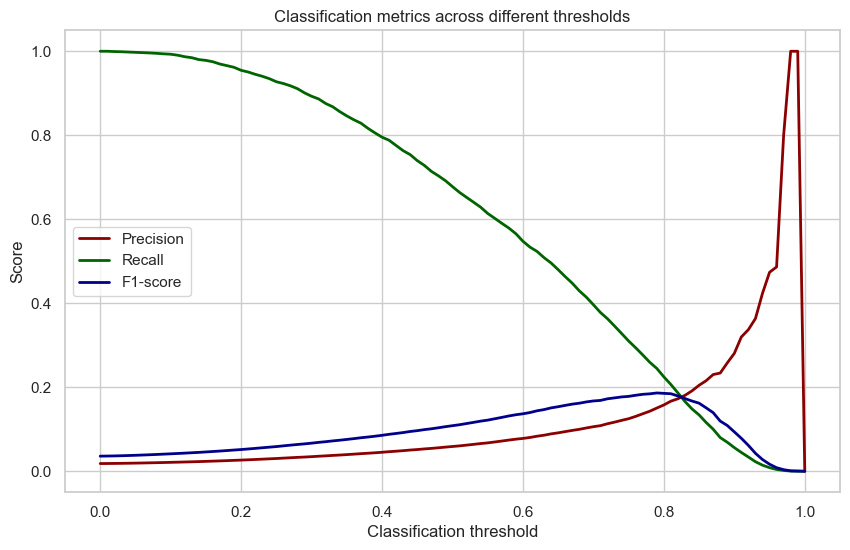

In [15]:
plot_threshold(y_te,  proba_xgb_full)

### Model interpretability

### Logistic Regression 

In [16]:
# Logistic Regression coefficients
def get_logistic_coefficients(model_logreg, X_test_df: pd.DataFrame):

    # Access logistic regression from the pipeline
    clf = model_logreg.named_steps['logisticregression']

    # Extract coefficients
    coefficients = clf.coef_.ravel()

    # Create table
    coef_table = pd.DataFrame({
        "feature": X_test_df.columns,
        "coefficient": coefficients,
        "odds_ratio": np.exp(coefficients),
        "direction": np.where(coefficients > 0, "positive", "negative")
    })

    # Sort by absolute value of coefficients
    coef_table = coef_table.sort_values(
        "coefficient",
        key=np.abs,
        ascending=False
    ).reset_index(drop=True)

    return coef_table


# Run coefficient extraction
coef_table = get_logistic_coefficients(model_logreg, X_te)

TOP_K = 15
coef_top = coef_table.head(TOP_K).round(3)

print(coef_top)

                  feature  coefficient  odds_ratio direction
0        EtCO2_is_missing       -0.281       0.755  negative
1                      HR        0.252       1.287  positive
2                    Resp        0.229       1.257  positive
3         FiO2_is_missing       -0.222       0.801  negative
4                    Temp        0.206       1.229  positive
5   BaseExcess_is_missing       -0.106       0.900  negative
6                     DBP       -0.098       0.907  negative
7                     MAP       -0.090       0.914  negative
8             HospAdmTime       -0.084       0.920  negative
9                  Gender        0.047       1.049  positive
10   Potassium_is_missing       -0.047       0.954  negative
11                    BUN        0.034       1.035  positive
12                     pH        0.024       1.025  positive
13                  O2Sat       -0.021       0.979  negative
14                    SBP        0.021       1.022  positive


### Random Forest

In [17]:
# Random Forest feature importance
importance = model_rf.feature_importances_

feature_names = getattr(model_rf, "feature_names_in_", None)

if isinstance(feature_names, np.ndarray):
    feature_names = feature_names.tolist()

if feature_names is None:
    feature_names = [f"var_{i}" for i in range(len(importance))]

rf_importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(rf_importance_df.head(20))

                  feature  importance
0                    Temp    0.209296
1             HospAdmTime    0.186889
2                    Resp    0.085982
3                      HR    0.084215
4        EtCO2_is_missing    0.082591
5         FiO2_is_missing    0.061287
6                     DBP    0.024477
7                     Age    0.023828
8                     SBP    0.023652
9                     MAP    0.023246
10       PaCO2_is_missing    0.016782
11                  O2Sat    0.016505
12          pH_is_missing    0.014034
13  BaseExcess_is_missing    0.012732
14             BaseExcess    0.009951
15                   FiO2    0.009617
16                  EtCO2    0.009453
17                    BUN    0.009153
18                    Hgb    0.008591
19              Magnesium    0.008579


### XGBoost 

In [18]:
# XGBoost feature importance
importance = model_xgb_full.feature_importances_

feature_names = getattr(model_xgb_full, "feature_names_in_", None)

if isinstance(feature_names, np.ndarray):
    feature_names = feature_names.tolist()

if feature_names is None:
    feature_names = [f"var_{i}" for i in range(len(importance))]

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(importance_df.head(20))

        feature  importance
0          FiO2    0.106876
1          Temp    0.102742
2         EtCO2    0.086651
3   HospAdmTime    0.076245
4          Resp    0.052814
5            HR    0.050994
6    BaseExcess    0.044529
7        Gender    0.040833
8           Age    0.040248
9           MAP    0.038016
10          DBP    0.037480
11           pH    0.035674
12        O2Sat    0.034620
13          BUN    0.033371
14          SBP    0.033248
15      Glucose    0.024296
16        PaCO2    0.022499
17          WBC    0.020827
18   Creatinine    0.020589
19          Hct    0.018773


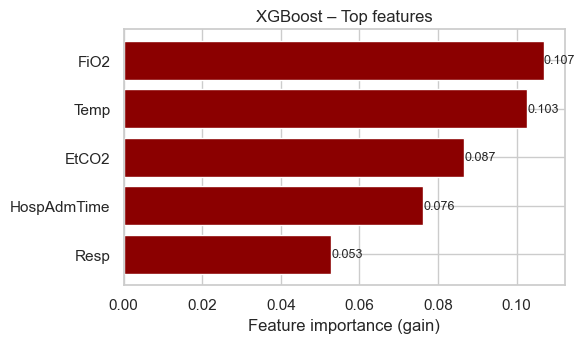

In [19]:
# XGBoost importance plot

top5_xgb = importance_df.nlargest(5, "importance").iloc[::-1]

plt.figure(figsize=(6, 3.6))

plt.barh(top5_xgb["feature"], top5_xgb["importance"], color="darkred")

for i, value in enumerate(top5_xgb["importance"]):
    plt.text(value, i, f"{value:.3f}", va='center', ha='left', fontsize=9)

plt.xlabel("Feature importance (gain)")
plt.title("XGBoost – Top features")

plt.tight_layout()
plt.show()